In [23]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
from pathlib import Path
import cmcrameri.cm as cmc

In [2]:
# 1. Loading the cleaned data of Zueriwieneu requests, neighbourhoods and population
reports_gdf = gpd.read_file("../data/cleaned/stzh.zwn_meldungen_p_cleaned.gpkg")
pop_quartiere_gdf = gpd.read_file("../data/cleaned/pop_quartiere_2013_2025.gpkg")
quartiere_gdf = gpd.read_file("../data/raw/quartiere.gpkg", layer="stzh.adm_statistische_quartiere_v")
quartiere_labels_gdf = gpd.read_file("../data/raw/quartiere.gpkg", layer="stzh.adm_statistische_quartiere_b_p")

# 2. Assign reports to their nearest neighbourhoods (a few lie just directly outside the city boarder, thus "nearest" was used instead of "within" or "intersects")
reports_quartier = gpd.sjoin_nearest(
    reports_gdf,
    pop_quartiere_gdf,
    how="left"
)

print(f"{reports_quartier['qname'].isna().sum()} reports were not assigned to a neighbourhood")

# 3. Define output file path
output_fp = Path(
    "C:/Users/lukas/OneDrive/Desktop/Privat/UZH/FS 26/Spatial Programming/sds210_project/outputs"
)

0 reports were not assigned to a neighbourhood


In [3]:
display(quartiere_labels_gdf.head())

,objid,objectid,ori,hali,vali,name,kuerzel,geometry
0,1,1,0.0,1.0,2.0,Affoltern,111,POINT (2680575.711 1253034.933)
1,2,2,0.0,1.0,2.0,Seebach,119,POINT (2683071.957 1253148.375)
2,3,3,0.0,1.0,2.0,Saatlen,121,POINT (2684968.446 1251835.404)
3,4,4,0.0,1.0,2.0,Höngg,101,POINT (2679781.451 1251349.147)
4,5,5,0.0,1.0,2.0,Wipkingen,102,POINT (2681888.652 1250165.853)


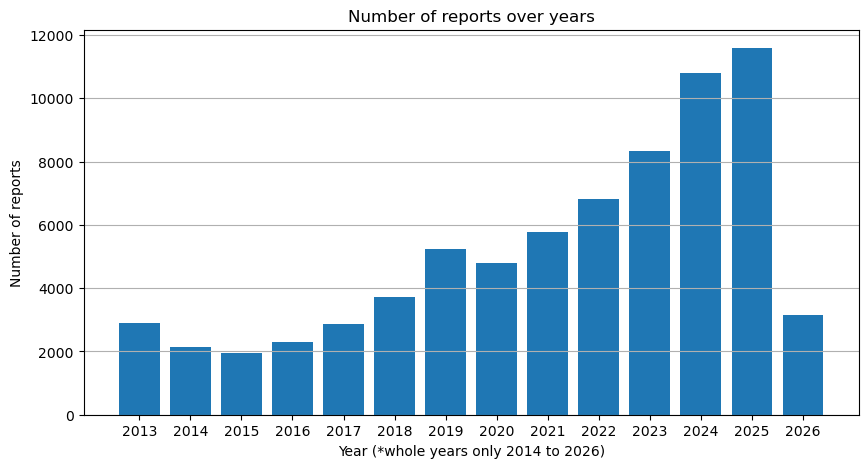

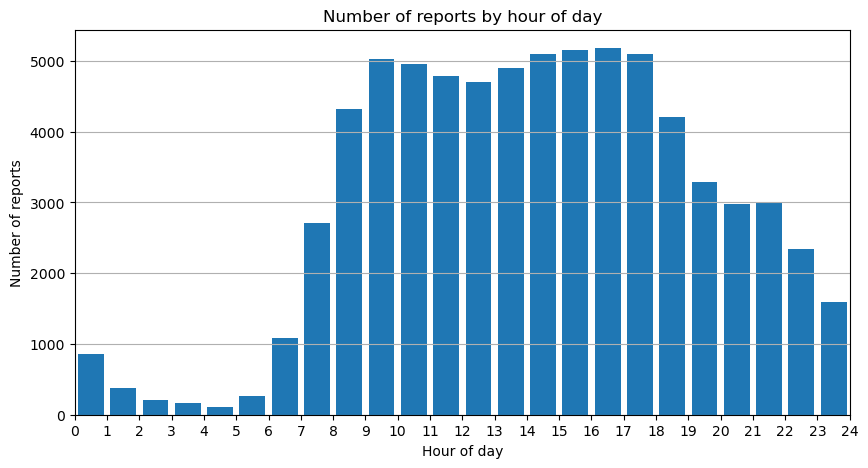

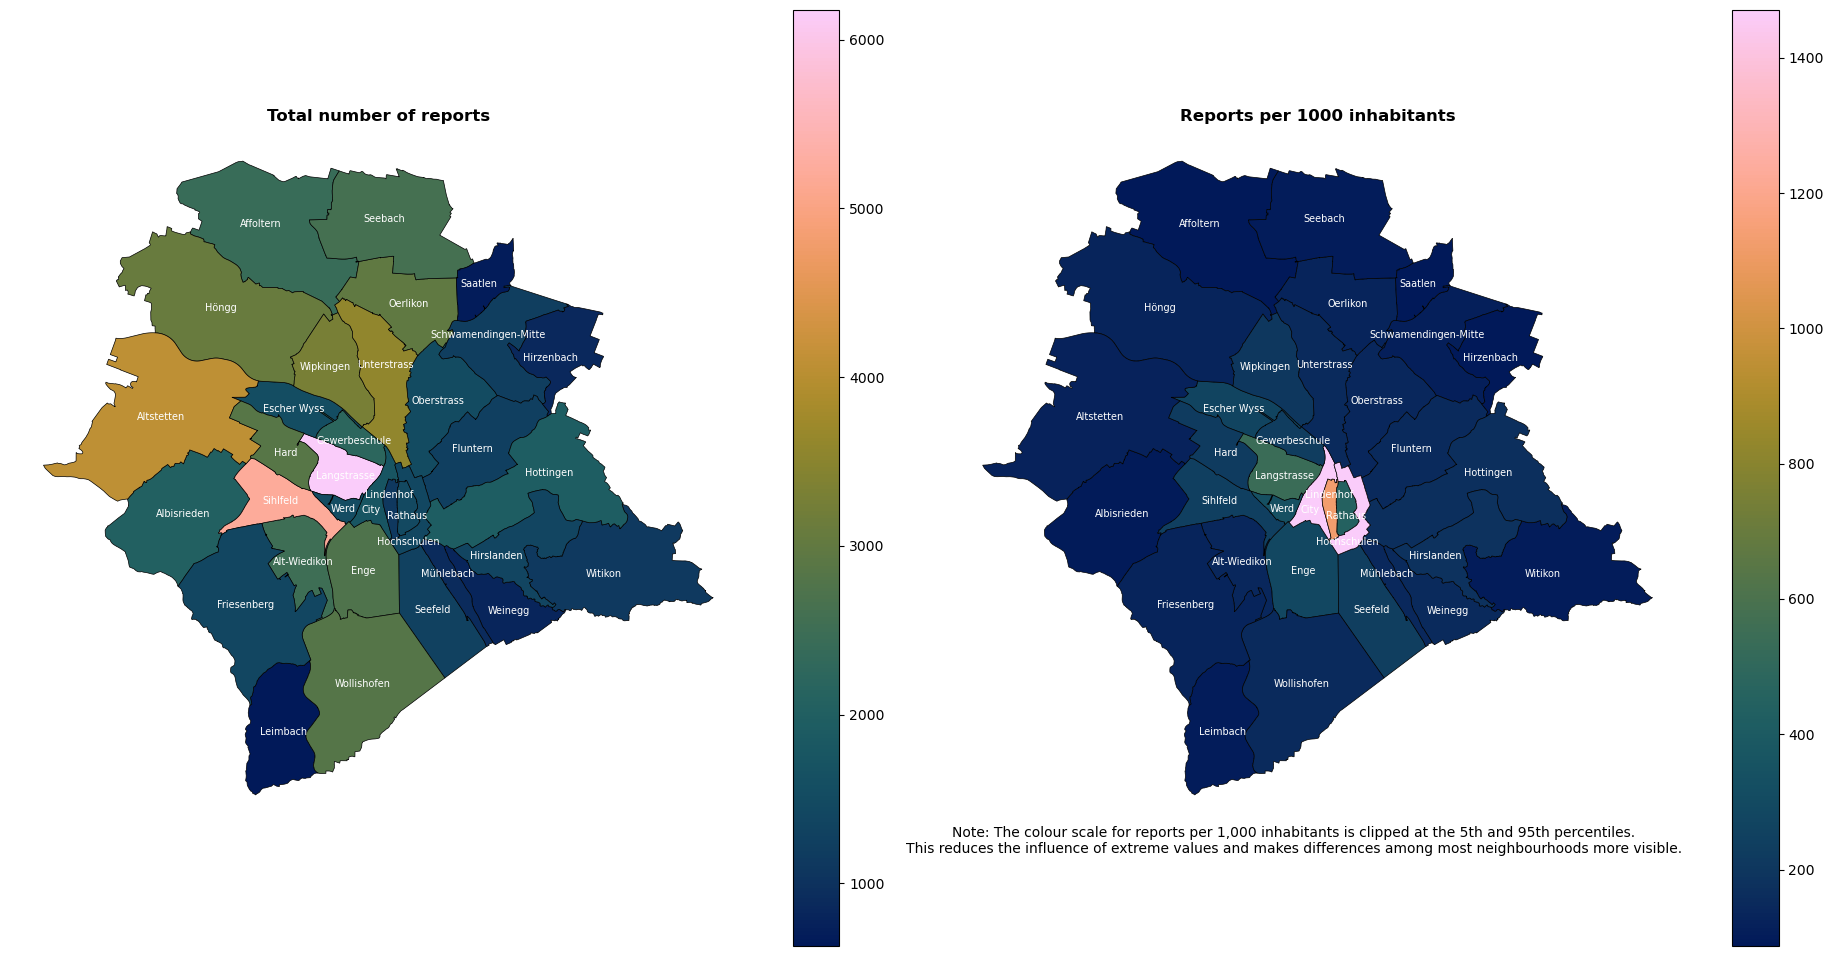

In [55]:
# (1) How does number of reports evolve over the years, diurnal and across neighbourhoods?

# Extract year
reports_gdf["year"] = (
    reports_gdf["requested_datetime"].dt.year
)

# (1.1) Count the total number of reports per year
report_counts_year = (
    reports_gdf
    .groupby("year")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per year with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    report_counts_year["year"],
    report_counts_year["report_count"]
)

plt.title("Number of reports over years")
plt.xlabel("Year (*whole years only 2014 to 2026)")
plt.ylabel("Number of reports")

# every year as tick
plt.xticks(report_counts_year["year"])

plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "reports_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Extract hour of day
reports_gdf["hour"] = reports_gdf["requested_datetime"].dt.hour

# (1.2) Count the total number of reports per hour
report_counts_hour = (
    reports_gdf
    .groupby("hour")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per hour with a bar chart
plt.figure(figsize=(10, 5))

# bars centered between hour ticks
x_positions = report_counts_hour["hour"] + 0.5

plt.bar(
    x_positions,
    report_counts_hour["report_count"],
    width=0.8
)

plt.title("Number of reports by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Number of reports")

# ticks at hour boundaries
plt.xticks(range(0, 25))

plt.xlim(0, 24)

plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "reports_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)
        
plt.show()


# (1.3) Count total reports per neighbourhood normalized by mean population from 2013-2025

# Asses mean population over the reporting period
population_cols = [
    "2013", "2014", "2015", "2016", "2017",
    "2018", "2019", "2020", "2021", "2022",
    "2023", "2024", "2025"
]

pop_quartiere_gdf["mean_pop_2013-2025"] = (
    pop_quartiere_gdf[population_cols]
    .mean(axis=1)
)
report_counts_quartier = (
    reports_quartier
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

# Join counts back to neighbourhood polygons/population
quartier_analysis = pop_quartiere_gdf.merge(
    report_counts_quartier,
    on="qname",
    how="left"
)

# Calculate reports per 1000 inhabitants
quartier_analysis["reports_per_1000"] = (
    quartier_analysis["report_count"]
    / quartier_analysis["mean_pop_2013-2025"]
) * 1000

# plot total reports and normalized reports as choropleths of neighbourhoods side-by-side
fig, axes = plt.subplots(
    1, 2, 
    figsize=(24, 12),    
    constrained_layout=False    
)

# Decrease unnecessary white space between subplots
plt.subplots_adjust(
    wspace=0.02,
    bottom=0.10
)

# use same colormap
cmap = "cmc.batlow"

# (Left map) total reports
quartier_analysis.plot(
    column="report_count",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title("Total number of reports", fontsize=12, fontweight="bold")
axes[0].axis("off")

# (Right map) reports per 1000 inhabitants
# Calculate the 5% and 95% quantiles to scale the display.
vmin = quartier_analysis["reports_per_1000"].quantile(0.05)
vmax = quartier_analysis["reports_per_1000"].quantile(0.95)
quartier_analysis.plot(
    column="reports_per_1000",
    cmap=cmap,
    legend=True,
    vmin=vmin,
    vmax=vmax,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[1]
)

axes[1].set_title("Reports per 1000 inhabitants", fontsize=12, fontweight="bold")
axes[1].axis("off")

# Add note below the figure
fig.text(
    0.66, 0.2,
    "Note: The colour scale for reports per 1,000 inhabitants is clipped at the 5th and 95th percentiles.\n"
    "This reduces the influence of extreme values and makes differences among most neighbourhoods more visible.",
    ha="center",
    va="top",
    fontsize=10
)


# add neighbourhood labels from label points layer
for ax in axes:

    for idx, row in quartiere_labels_gdf.iterrows():

        x = row.geometry.x
        y = row.geometry.y

        # manual adjustments of two overlapping labels in the centre
        if row["name"] == "Lindenhof":
            y += 100

        if row["name"] == "Rathaus":
            y -= 200

        ax.text(
            x,
            y,
            row["name"],
            fontsize=7,
            color="white",
            ha="center",
            va="center"
        )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_reports_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

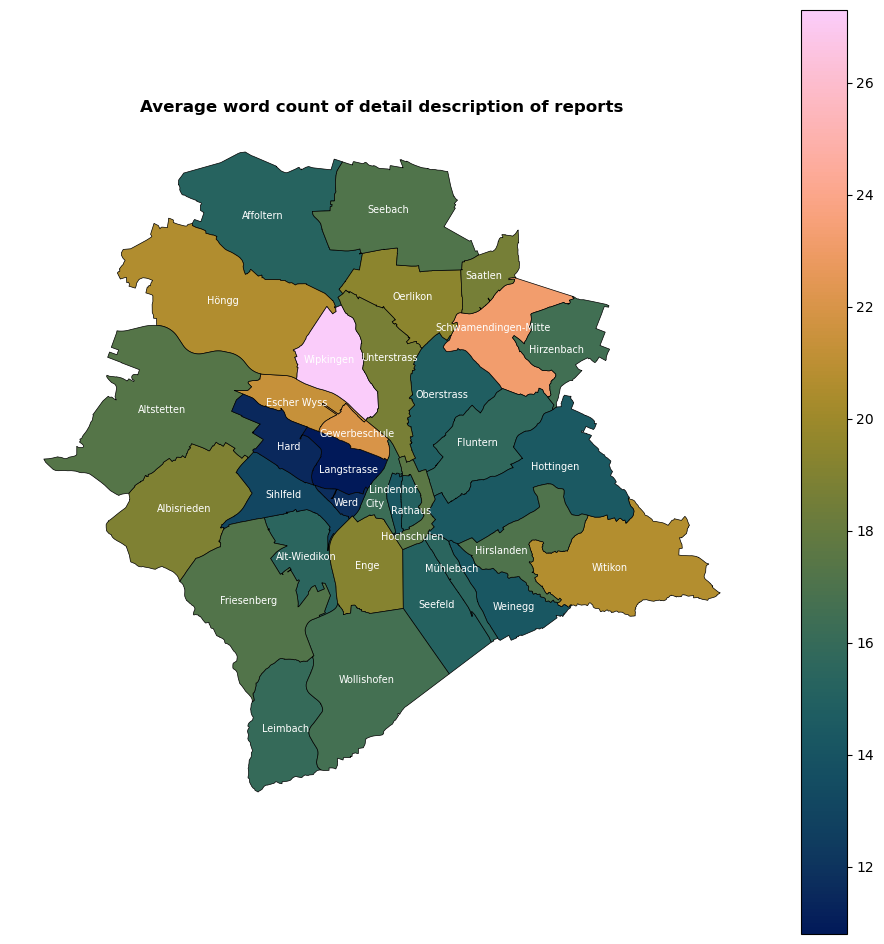

In [37]:
# (2) Which neighbourhoods make the most detailed reports (average number of words)?

# Count words in each report detail
reports_quartier["word_count"] = (
    reports_quartier["detail"]
    .str.split() # splits detail in a list of single words
    .str.len() # counts length of the list
)

# Average words per neighbourhood
avg_word_count = (
    reports_quartier
    .groupby("qname")["word_count"]
    .mean()
    .reset_index(name="avg_word_count")
    .sort_values("avg_word_count", ascending=False)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    avg_word_count,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))

# use same colormap
cmap = "cmc.batlow"

quartier_analysis.plot(
    column="avg_word_count",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Average word count of detail description of reports", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")


# add neighbourhood labels from label points layer
for idx, row in quartiere_labels_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    # manual adjustments of two overlapping labels in the centre
    if row["name"] == "Lindenhof":
        y += 100

    if row["name"] == "Rathaus":
        y -= 200

    ax.text(
        x,
        y,
        row["name"],
        fontsize=7,
        color="white",
        ha="center",
        va="center"
    )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_word_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

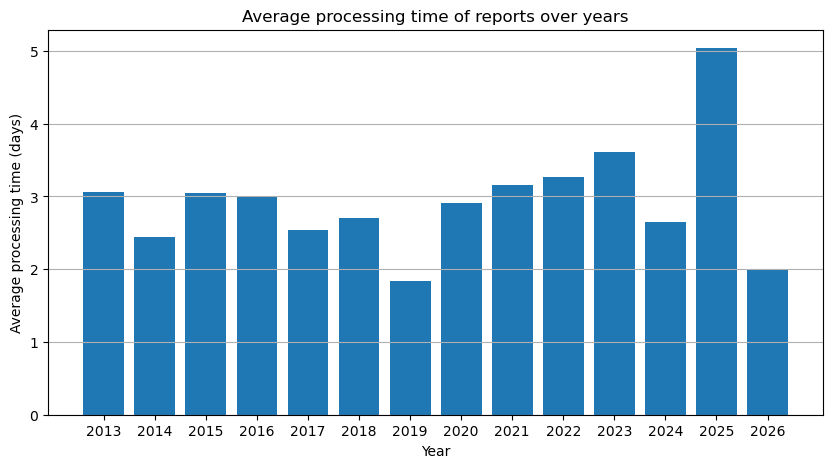

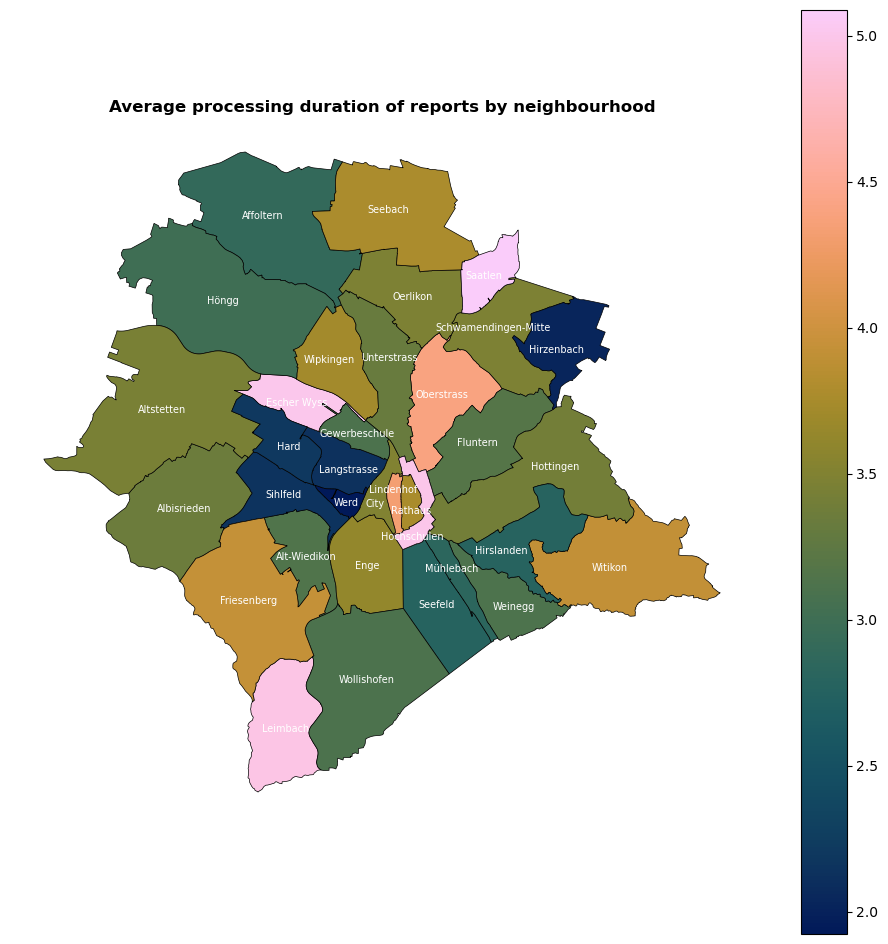

In [38]:
# (3) How long does the processing of the reports by the council take? Did it change over time and neighbourhoods? (only for reports with "status"="fixed - council")

# Define only the reports that were fixed by the municipal offices
fixed_reports = reports_quartier[
    reports_quartier["status"] == "fixed - council"
].copy()

# Calculate processing duration for these reports
fixed_reports["processing_time"] = (
    fixed_reports["updated_datetime"]
    - fixed_reports["requested_datetime"]
)

# recalcualte processing duration to decimal days
fixed_reports["processing_days"] = (
    fixed_reports["processing_time"]
    .dt.total_seconds() / (60 * 60 * 24)
)

# Extract year
fixed_reports["year"] = (
    fixed_reports["requested_datetime"].dt.year
)

# (3.1) Count the average processing duration per year
processing_time_year = (
    fixed_reports
    .groupby("year")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("year", ascending=True)
)

# Plot the the evolution of average processing time with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    processing_time_year["year"],
    processing_time_year["avg_processing_days"]
)

plt.title("Average processing time of reports over years")
plt.xlabel("Year")
plt.ylabel("Average processing time (days)")

# every year as tick
plt.xticks(processing_time_year["year"])
plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "processing_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# (3.2) Count the average processing duration per neighbourhood
processing_time_by_quartier = (
    fixed_reports
    .groupby("qname")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("avg_processing_days", ascending=True)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    processing_time_by_quartier,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))

# use same colormap
cmap = "cmc.batlow"

quartier_analysis.plot(
    column="avg_processing_days",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title(
    "Average processing duration of reports by neighbourhood", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")

# add neighbourhood labels from label points layer
for idx, row in quartiere_labels_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    # manual adjustments of two overlapping labels in the centre
    if row["name"] == "Lindenhof":
        y += 100

    if row["name"] == "Rathaus":
        y -= 200

    ax.text(
        x,
        y,
        row["name"],
        fontsize=7,
        color="white",
        ha="center",
        va="center"
    )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_processing_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

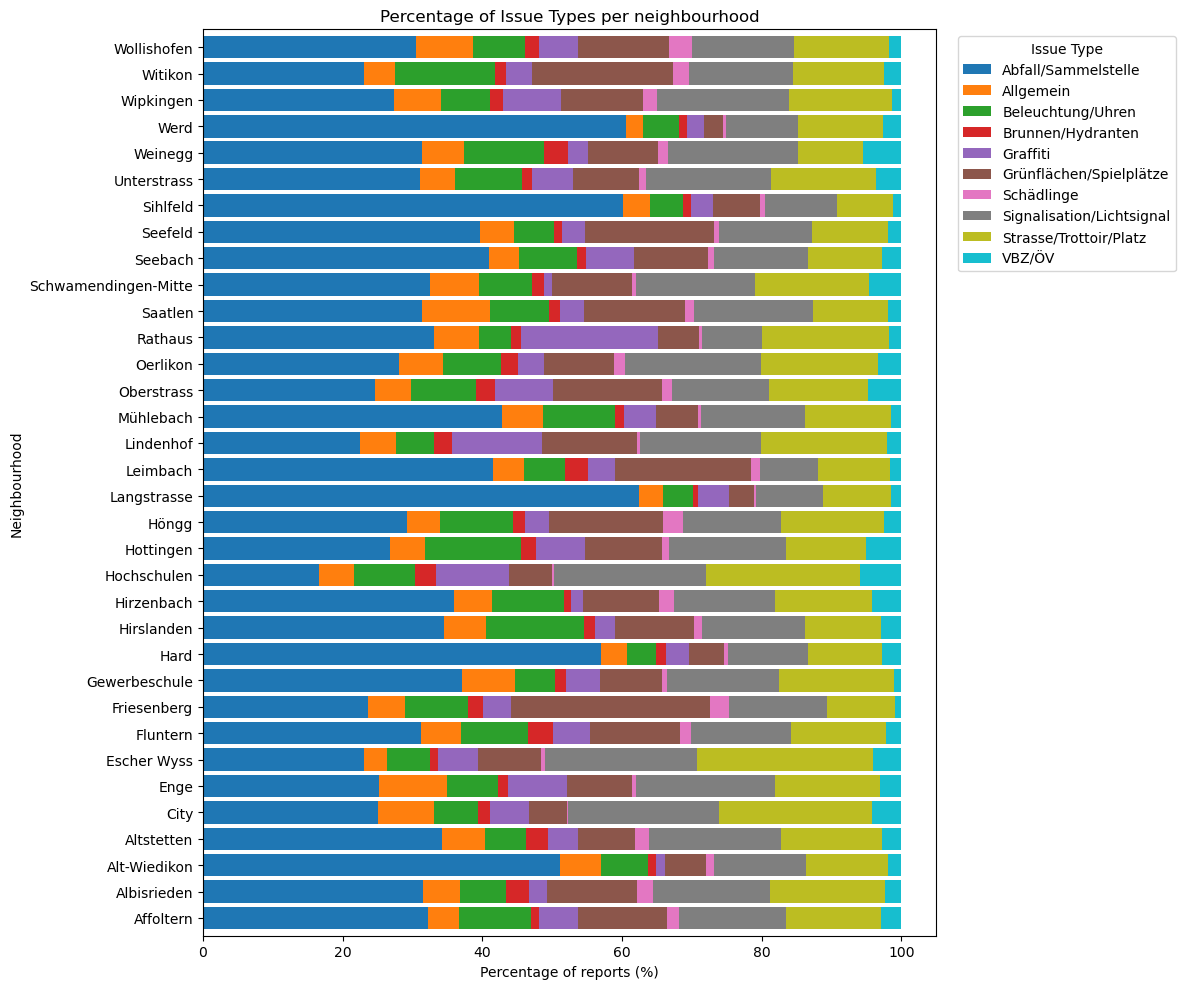

In [7]:
# (4) What percentage of reports in a neighbourhood belong to each issue type?
# Count issue types per neighbourhood
issue_by_quartier = (
    reports_quartier
    .groupby(["qname", "service_name"])
    .size()
    .reset_index(name="report_count")
)

# Calculate absolute number of total reports per neighbourhood
quartier_totals = (
    reports_quartier
    .groupby("qname")
    .size()
    .reset_index(name="total_reports")
)

# Join totals back
issue_by_quartier = issue_by_quartier.merge(
    quartier_totals,
    on="qname",
    how="left"
)

# Calculate share of each issue category for each neighbourhood
issue_by_quartier["share_of_reports"] = (
    issue_by_quartier["report_count"]
    / issue_by_quartier["total_reports"]
) * 100

# Build a pivot table of shares and types of reports
issue_pivot = issue_by_quartier.pivot(
    index="qname",
    columns="service_name",
    values="share_of_reports"
).fillna(0)

# Plot the pivot table as stacked bars
ax = issue_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 10),
    width=0.85
)

ax.set_xlabel("Percentage of reports (%)")
ax.set_ylabel("Neighbourhood")
ax.set_title("Percentage of Issue Types per neighbourhood")

# Format and localize the legend box
ax.legend(
    title="Issue Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# save figure to output-folder
plt.savefig(
    output_fp / "service_type_shares.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

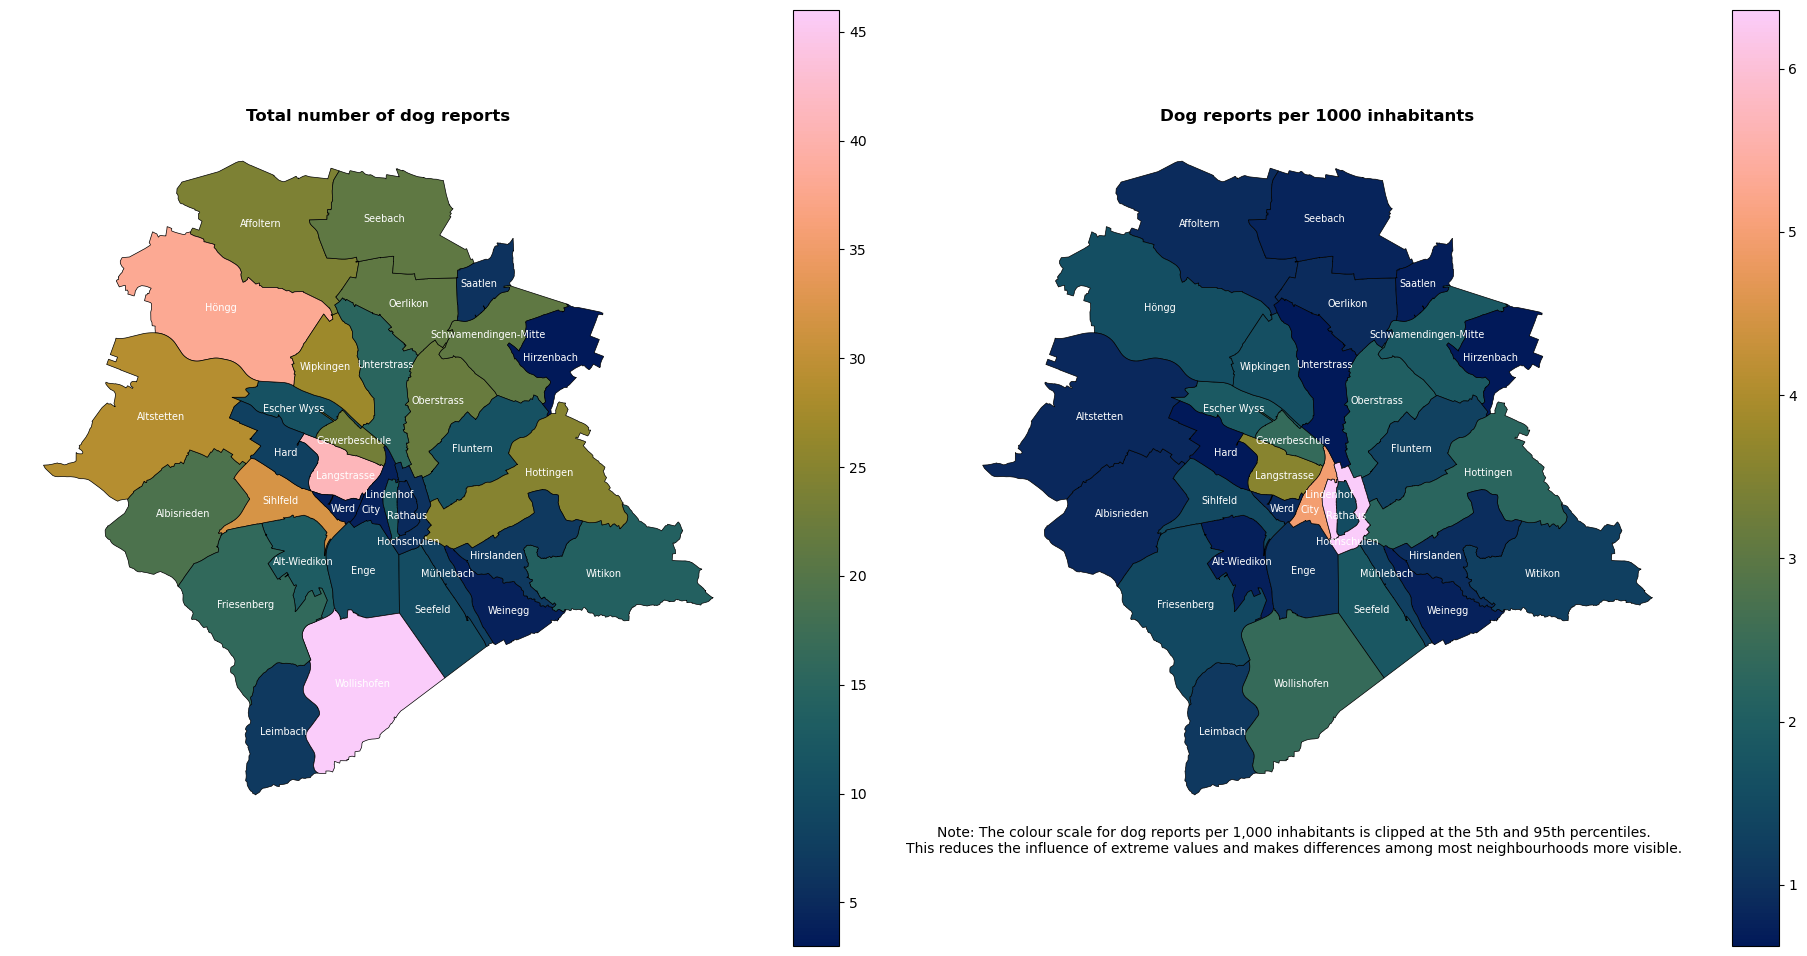

In [53]:
# (5) Which neighbourhood report the most dog-related problems? (use LLM to assess which wordings are searched in descriptions and titles)?

# 1. Normalize text of "detail"-column to make keyword search work
reports_quartier["detail"] = (
    reports_quartier["detail"]
    .fillna("") # replaces potential NaN with empty strings
    .astype(str) # ensures that all detail descriptions are text (strings)
    .str.lower() # converts all text in "detail" to lowercase
)

# 2. search for word stem "hund" but exclude "hundert(e)" using the regex syntax
hund_reports = reports_quartier[
    reports_quartier["detail"].str.contains(
        r"\b\w*hund(?!ert)\w*\b",
        regex=True
    )
].copy()

# 3. Visualize the dog reports on neighbourhood level (absolute and relative per 1000 inhabitants)
############## delete later, only to run the cell more then once
quartier_analysis = quartier_analysis.drop(
    columns=["hund_reports_count", "hund_reports_count_x", "hund_reports_count_y" "hund_reports_per_1000"],
    errors="ignore"
)

# Count number of dog problems per neighbourhood
hund_by_quartier = (
    hund_reports
    .groupby("qname")
    .size()
    .reset_index(name="hund_reports_count")
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    hund_by_quartier,
    on="qname",
    how="left"
)

# Calculate dog-related reports per 1,000 inhabitants
quartier_analysis["hund_reports_per_1000"] = (
    quartier_analysis["hund_reports_count"]
    / quartier_analysis["mean_pop_2013-2025"]
) * 1000

# plot total dog reports and normalized dog reports as choropleths of neighbourhoods side-by-side
fig, axes = plt.subplots(
    1, 2, 
    figsize=(24, 12),
    constrained_layout=False    
)

# Decrease unnecessary white space between subplots
plt.subplots_adjust(
    wspace=0.02,
    bottom=0.10
)

# use same colormap
cmap = "cmc.batlow"

# (Left map) total reports
quartier_analysis.plot(
    column="hund_reports_count",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title("Total number of dog reports", fontsize=12, fontweight="bold")
axes[0].axis("off")

# (Right map) reports per 1000 inhabitants
# Calculate the 5% and 95% quantiles to scale the display.
vmin = quartier_analysis["hund_reports_per_1000"].quantile(0.05)
vmax = quartier_analysis["hund_reports_per_1000"].quantile(0.95)

quartier_analysis.plot(
    column="hund_reports_per_1000",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[1]
)

axes[1].set_title("Dog reports per 1000 inhabitants", fontsize=12, fontweight="bold")
axes[1].axis("off")

# Add note below the figure
fig.text(
    0.66, 0.2,
    "Note: The colour scale for dog reports per 1,000 inhabitants is clipped at the 5th and 95th percentiles.\n"
    "This reduces the influence of extreme values and makes differences among most neighbourhoods more visible.",
    ha="center",
    va="top",
    fontsize=10
)

# add neighbourhood labels from label points layer
for ax in axes:

    for idx, row in quartiere_labels_gdf.iterrows():

        x = row.geometry.x
        y = row.geometry.y

        # manual adjustments of two overlapping labels in the centre
        if row["name"] == "Lindenhof":
            y += 100

        if row["name"] == "Rathaus":
            y -= 200

        ax.text(
            x,
            y,
            row["name"],
            fontsize=7,
            color="white",
            ha="center",
            va="center"
        )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_reports_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [20]:
display(quartier_analysis.head(34))

,qname,2013,2014,2015,2016,2017,2018,2019,2020,2021,...,2025,geometry,mean_pop_2013-2025,report_count,reports_per_1000,avg_word_count,avg_processing_days,hund_reports_count_y,hund_reports_per_1000,hund_reports_count
0,Alt-Wiedikon,16706,16918,17158,17321,17522,17956,17874,17764,17631,...,18904,"POLYGON ((2680606.662 1247034.584, 2680626.356...",17735.230769,2495,140.680436,15.486573,3.135239,13,0.733004,13
1,Witikon,10267,10406,10639,10667,10600,10953,11054,11244,11255,...,11984,"POLYGON ((2685858.632 1246502.629, 2685860.738...",11069.846154,1130,102.079106,20.708850,3.920960,14,1.264697,14
2,Langstrasse,10686,10985,11169,11145,11144,11111,11853,11910,11815,...,11978,"POLYGON ((2681313.304 1248613.857, 2681459.605...",11509.538462,6175,536.511522,10.802429,2.122421,41,3.562263,41
3,Escher Wyss,4010,4604,5457,5825,6088,6066,6188,6198,6221,...,6426,"POLYGON ((2680009.144 1249565.021, 2680055.843...",5813.076923,1558,268.016409,21.329268,5.004916,11,1.892285,11
4,Enge,8836,9083,9257,9422,9489,9634,9658,9655,9750,...,10015,"POLYGON ((2681898.171 1246379.668, 2681899.115...",9606.384615,2739,285.122875,19.186564,3.619071,10,1.040974,10
5,Weinegg,5022,5036,5086,5030,5248,5220,5414,5562,5548,...,5701,"POLYGON ((2684268.476 1246568.755, 2684268.988...",5357.692308,808,150.811199,14.238861,3.113380,4,0.746590,4
6,Seefeld,4978,5035,4990,5046,5129,5253,5319,5480,5862,...,5798,"POLYGON ((2683358.477 1246403.556, 2683604.467...",5406.846154,1279,236.551950,15.159500,2.769765,10,1.849507,10
7,Leimbach,5730,5936,6102,6173,6212,6320,6152,6140,6338,...,6316,"POLYGON ((2680272.556 1242790.921, 2680279.734...",6209.153846,629,101.302048,16.019078,4.976243,7,1.127368,7
8,Wollishofen,15937,16137,16244,16567,17892,18923,19225,19757,19937,...,22029,"POLYGON ((2681416.928 1244793.441, 2681418.119...",18938.384615,2827,149.273555,16.611956,3.098717,46,2.428929,46
9,Mühlebach,5912,6107,6116,6137,6164,6315,6327,6414,6408,...,6437,"POLYGON ((2683784.262 1246610.465, 2683801.581...",6286.692308,905,143.954874,15.491713,2.829791,8,1.272529,8
